# AAV9 Potts GT -- simulated-replicate stochasticity (10 parallel `Protocol` runs)

Real `fit4functionaav9.csv` has exactly 2 replicates (`Production1`/`Production2`), whose
agreement (`r_replicate_ceiling = 0.891`, `AAV9_fit4function_potts_vs_mlp.ipynb` section 3) sets
the reproducibility ceiling every fitted method there was measured against. This notebook asks
the mirror question: if we simulate the SAME experiment 10 independent times with the
`Protocol` engine (seeded with the real AAV9 Potts-regression GT, `F_potts`/`J_potts`, on the
exact same amino-acid sequences as `fit4functionaav9.csv`), does the simulator's own
replicate-to-replicate stochasticity (NGS sampling noise, per-cell `noise_viab`) land in the
same ballpark as the real experiment's replicate noise -- or is the simulated protocol
noticeably more/less reproducible than the real one?

10 independent `loop_DE()` runs on the SAME `protocol` object (fresh stochastic draw each
call, weights/sequences/hyperparameters held fixed) stand in for 10 "parallel production
experiments." `replicate_1` is used as the fixed x-axis reference throughout (mirroring how
`Production1` was the fixed x-axis in the real-data notebook).

## 0. Setup

In [1]:
import sys, os

# Locate Modelization_V2/lib by walking up from the cwd (= this notebook's dir). A hardcoded
# "../../lib" breaks every time the notebook is moved between subfolders of
# Modelization_V2/notebooks/ -- and when it points nowhere, `import sequence_classesV1`
# silently resolves to Modelization_V1's pip-installed copy (whose Protocol.__init__ has no
# `key` arg -> TypeError downstream). V2 has no editable install on purpose (name collision
# with V1), so this sys.path entry is the only thing pointing imports at the V2 lib.
_d = os.path.abspath("")
while os.path.basename(_d) != "Modelization_V2" and _d != os.path.dirname(_d):
    _d = os.path.dirname(_d)
_V2_LIB = os.path.join(_d, "lib")
assert os.path.isdir(_V2_LIB), f"Modelization_V2/lib not found walking up from {os.path.abspath('')}"
sys.path.insert(0, _V2_LIB)
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from analysisV1 import AA_LABELS, pearson
from sequence_classesV1 import ProtocolV3
from initialize_weights import load_F_viab_aav9_potts, load_J_viab_aav9_potts, NUM_AMINO_ACIDS, NUM_POSITIONS

import sequence_classesV1 as _scv1
assert "Modelization_V2" in _scv1.__file__, f"imported the wrong sequence_classesV1: {_scv1.__file__}"

# Pseudocount for the SIMULATED side only (`viability_target1`, section 2b): `lambda0p`/
# `lambda2p` are raw simulated read counts, which can be exactly 0, so a pseudocount is needed
# before taking a log. `Production1`/`Production2` (section 1b) are the real, already-computed
# fold-enrichment ratios from `fit4functionaav9.csv`, not raw counts -- an exact 0 there is
# dropped instead (see section 1b), not pseudocounted a second time.
eps = 1

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")
print(f"sequence_classesV1: {_scv1.__file__}")

message = "AAV9 Potts GT: 10 simulated-replicate stochasticity check, 1.0"

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX backend: gpu -- devices: [CudaDevice(id=0)]
sequence_classesV1: /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/sequence_classesV1.py


In [2]:
df = pd.read_csv("fit4functionaav9.csv")
print(f"{len(df):,} rows, columns: {list(df.columns)}")

lengths = df["AA"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
assert int(lengths[0]) == NUM_POSITIONS

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(df["AA"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), NUM_POSITIONS)
sequences  = jnp.asarray(seq_matrix)
d0         = sequences.shape[0]

print(f"seq_matrix shape: {seq_matrix.shape}")
print(f"d0 = {d0:,} sequences (same identities as fit4functionaav9.csv, duplicates included as-is)")

74,464 rows, columns: ['AA', 'CodonRep1', 'CodonRep2', 'Label', 'Production1', 'Production2', 'Production']
seq_matrix shape: (74464, 7)
d0 = 74,464 sequences (same identities as fit4functionaav9.csv, duplicates included as-is)


## 1b. Real Production1 vs Production2 (context)

Before comparing SIMULATED replicates against each other (sections 3-5), a look at what the
REAL replicate agreement actually looks like. `log2` (not natural log -- matches
`log_enrichment_histograms.ipynb` / `discordant_variants_aav9.ipynb` / the preview plot in
section 2b below), on rows where BOTH `Production1 > 0` AND `Production2 > 0` -- no pseudocount.
`Production1`/`Production2` are already the fold-enrichment ratio `fit4functionaav9.csv`
reports (not raw read counts), so an exact 0 is dropped rather than pseudocounted a second time
-- the same convention `log_enrichment_histograms.ipynb` already established for this exact
column. Same ~54,621-row both-nonzero population `AAV9_fit4function_potts_vs_mlp.ipynb` section
3 uses for its own `r_replicate_ceiling`.


kept 54,621/74,464 rows with a finite, strictly positive value in BOTH Production1 and Production2 (exact zeros dropped, no pseudocount)
r(Production1, Production2) = 0.8911


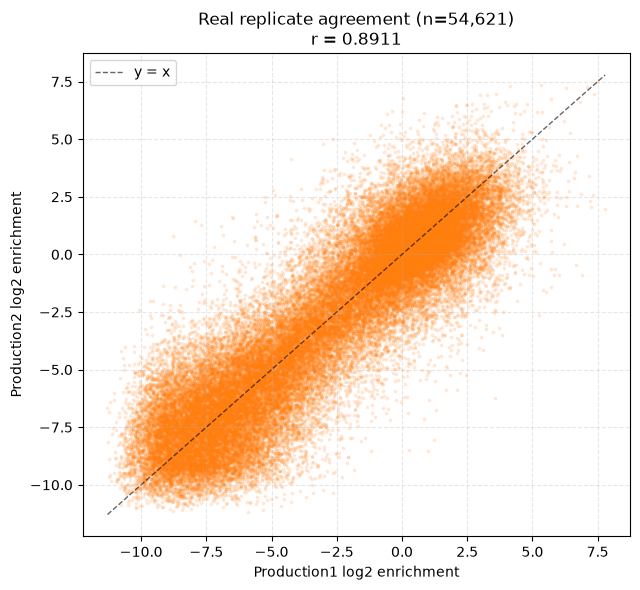

In [3]:
p1 = df["Production1"].to_numpy(dtype=float)
p2 = df["Production2"].to_numpy(dtype=float)
both_valid = np.isfinite(p1) & (p1 > 0) & np.isfinite(p2) & (p2 > 0)  # drop exact zeros, not pseudocount them
log_p1_real = np.log2(p1[both_valid])
log_p2_real = np.log2(p2[both_valid])

r_p1_p2_real = pearson(log_p1_real, log_p2_real)
print(f"kept {both_valid.sum():,}/{len(df):,} rows with a finite, strictly positive value in "
      f"BOTH Production1 and Production2 (exact zeros dropped, no pseudocount)")
print(f"r(Production1, Production2) = {r_p1_p2_real:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(log_p1_real, log_p2_real, s=3, alpha=0.12, color="tab:orange")
lo = min(log_p1_real.min(), log_p2_real.min())
hi = max(log_p1_real.max(), log_p2_real.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6, label="y = x")
ax.set_xlabel("Production1 log2 enrichment")
ax.set_ylabel("Production2 log2 enrichment")
ax.set_title(f"Real replicate agreement (n={both_valid.sum():,})\nr = {r_p1_p2_real:.4f}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()


## 2. Potts-regression GT weights + baseline protocol config

`F_potts`/`J_potts` -- the same real AAV9 Potts-regression GT used throughout `Modelization_V2`
(`AAV9_potts_regression.ipynb`). Baseline hyperparameters are the project's established
"realistic" operating point (`AAV9_fitting_protocol.ipynb` section 2, `N0=150*N1` per the
`N1/N0` lab ratio constraint used elsewhere in this project): `mu=50`, `T_viab=0.8`,
`noise_viab=0.5`, `D=1e9`. `F_sel`/`J_sel` are zero -- `loop_DE()` computes the viability log
enrichment BEFORE `selectivity()` runs, so they can't affect anything plotted below.

In [4]:
F_potts = load_F_viab_aav9_potts()
J_potts = load_J_viab_aav9_potts()

F_sel = jnp.zeros_like(F_potts)
J_sel = jnp.zeros_like(J_potts)

key              = jax.random.key(42)
RHO_REF          = 1e-3
MU_FIXED         = 50
T_VIAB_FIXED     = 1.3
NOISE_VIAB_FIXED = 0.5
D_FIXED          = 1e9
DILUTION_FACTOR  = 1e6
T_SEL_FIXED      = 1.0   # unused by target1, kept at the project default
eps              = 1

N1_FIXED = MU_FIXED * d0 / RHO_REF
N0_FIXED = N1_FIXED * 150

protocol = ProtocolV3(multinomialNGS=True, key=key, N0=N0_FIXED, N1=N1_FIXED,
        dilution_factor=DILUTION_FACTOR, sequences=sequences, D=D_FIXED,
        F_viab=F_potts, J_viab=J_potts, F_sel=F_sel, J_sel=J_sel,
        noise_viab=NOISE_VIAB_FIXED, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED,
        )

print(f"mu = {protocol._rho * protocol.N1 / d0:.2f}   N1={N1_FIXED:.3e}   N0={N0_FIXED:.3e}")
print(f"D/d0 (reads/sequence) = {D_FIXED / d0:.1f}")

mu = 50.00   N1=3.723e+09   N0=5.585e+11
D/d0 (reads/sequence) = 13429.3


### 2b. Sanity check: one simulated draw vs. the real Production1 distribution

Before running the full 10-replicate comparison below, a quick visual check: does a SINGLE
simulated draw from `protocol` -- using the tunable hyperparameters set in section 2 above
(`MU_FIXED`, `T_VIAB_FIXED`, `NOISE_VIAB_FIXED`, `D_FIXED`) -- even land in the right
ballpark, shape- and spread-wise, against the real `Production1` log2 enrichment? Same
validity filter as section 1b, applied to `Production1` alone here (the simulated side has no
equivalent "invalid" case -- every one of the `d0` sequences gets a `target1` value).

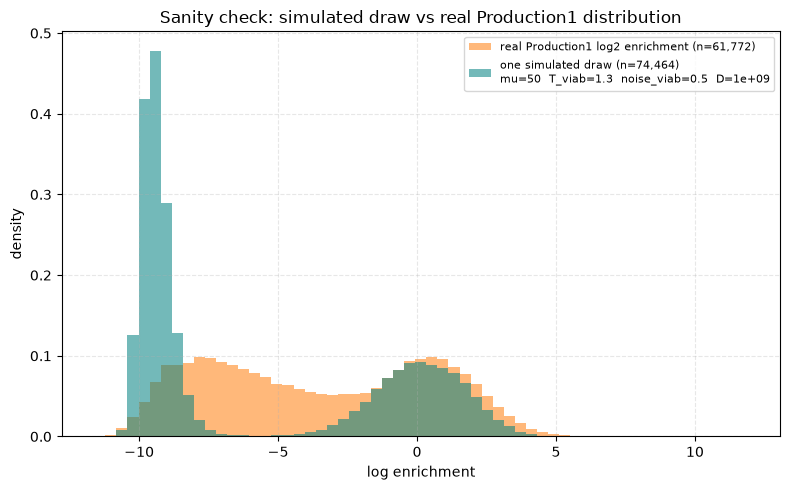

real Production1:   mean=-3.525  std=4.000
simulated preview:  mean=-5.692  std=4.756


In [5]:
def viability_target1(protocol, key, eps=eps):
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    protocol.key     = key
    _bio_row, ngs_row = protocol.loop_DE()
    lambda0p, lambda2p, _lambda3p = (np.asarray(a) for a in ngs_row)
    return np.log((lambda2p + eps) / (lambda0p + eps))


preview_run = viability_target1(protocol, jax.random.key(42))

p1_valid_only = np.isfinite(p1) & (p1 > 0)
log2_p1_preview = np.log2(p1[p1_valid_only])

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(min(log2_p1_preview.min(), preview_run.min()),
                    max(log2_p1_preview.max(), preview_run.max()), 60)
ax.hist(log2_p1_preview, bins=bins, alpha=0.55, density=True, color="tab:orange",
        label=f"real Production1 log2 enrichment (n={len(log2_p1_preview):,})")
ax.hist(preview_run, bins=bins, alpha=0.55, density=True, color="teal",
        label=f"one simulated draw (n={len(preview_run):,})\n"
              f"mu={MU_FIXED:.3g}  T_viab={T_VIAB_FIXED:.3g}  noise_viab={NOISE_VIAB_FIXED:.3g}  D={D_FIXED:.3g}")
ax.set_xlabel("log enrichment")
ax.set_ylabel("density")
ax.set_title("Sanity check: simulated draw vs real Production1 distribution")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"real Production1:   mean={log2_p1_preview.mean():+.3f}  std={log2_p1_preview.std():.3f}")
print(f"simulated preview:  mean={preview_run.mean():+.3f}  std={preview_run.std():.3f}")


## 3. 10 independent simulated replicates

Reuses `viability_target1` (defined in section 2b above): one `loop_DE()` round,
`target1 = log((lambda2p+eps)/(lambda0p+eps))`. `protocol.lambda0` is reset before each call
(`loop_DE()` depletes it in place) -- everything else (weights, sequences, hyperparameters)
stays fixed across all 10 calls, so the ONLY thing that differs run to run is the stochastic
draw (NGS multinomial sampling, per-cell `noise_viab` noise).

In [6]:
N_REPLICATES = 10
keys = jax.random.split(jax.random.key(13), N_REPLICATES)  # one subkey per replicate
replicates = {}
for i in range(1, N_REPLICATES + 1):
    replicates[i] = viability_target1(protocol, keys[i - 1])  # keys is 0-indexed
    print(f"replicate_{i}: mean={replicates[i].mean():+.3f}  std={replicates[i].std():.3f}")


replicate_1: mean=-5.701  std=4.752


replicate_2: mean=-5.692  std=4.752


replicate_3: mean=-5.690  std=4.751


replicate_4: mean=-5.694  std=4.751


replicate_5: mean=-5.687  std=4.757


replicate_6: mean=-5.700  std=4.754


replicate_7: mean=-5.701  std=4.757


replicate_8: mean=-5.692  std=4.751


replicate_9: mean=-5.691  std=4.758


replicate_10: mean=-5.695  std=4.754


## 4. `replicate_1` vs `replicate_i`, i in [1, 4]

Same "one replicate as the fixed x-axis" convention as
`AAV9_fit4function_potts_vs_mlp.ipynb`'s Production1-vs-Production2 comparison. `i=1` (against
itself) is included as a trivial sanity-check panel -- perfect diagonal, `r=1` by
construction.

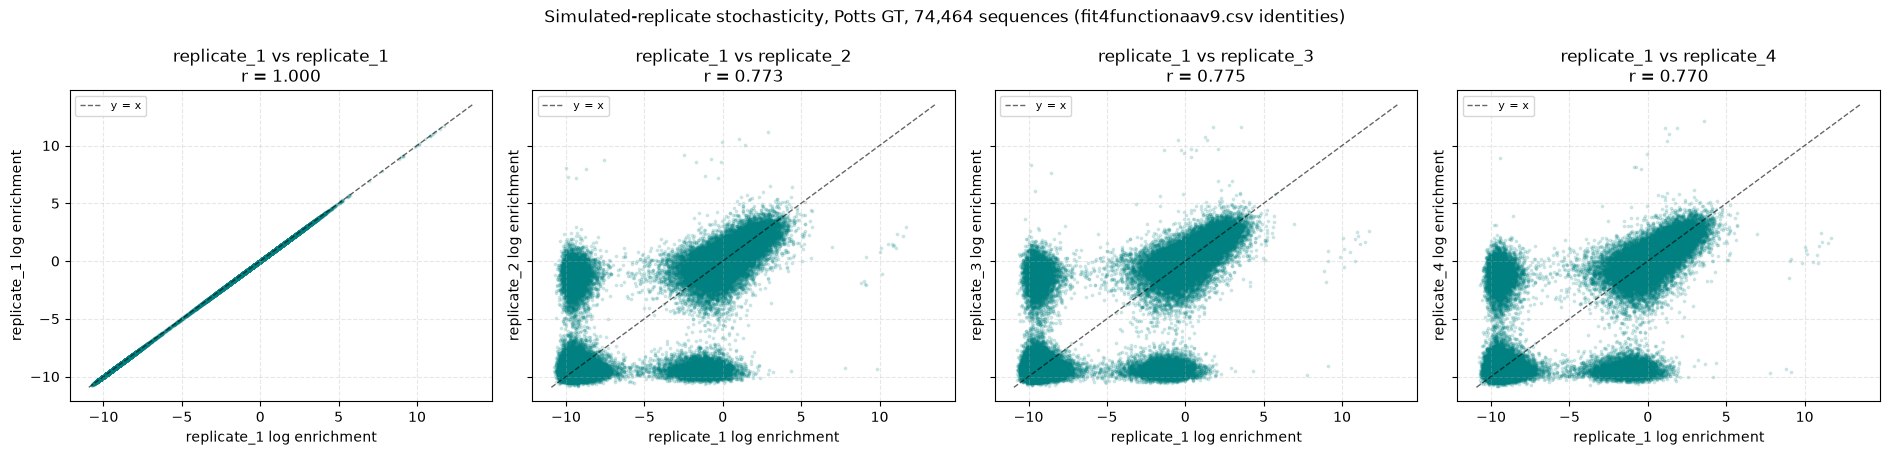

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.6), sharex=True, sharey=True)
lo = min(v.min() for v in replicates.values())
hi = max(v.max() for v in replicates.values())

for ax, i in zip(axes, range(1, 5)):
    r_i = pearson(replicates[1], replicates[i])
    ax.scatter(replicates[1], replicates[i], s=3, alpha=0.15, color="teal")
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6, label="y = x")
    ax.set_xlabel("replicate_1 log enrichment")
    ax.set_ylabel(f"replicate_{i} log enrichment")
    ax.set_title(f"replicate_1 vs replicate_{i}\nr = {r_i:.3f}")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle(f"Simulated-replicate stochasticity, Potts GT, {d0:,} sequences (fit4functionaav9.csv identities)")
fig.tight_layout()
plt.show()

## 5. Full pairwise stochasticity, all 10 replicates -- vs. the real replicate ceiling

Section 4 only shows `replicate_1` against 3 others. This computes Pearson r for all
`10*9/2 = 45` distinct replicate pairs (same "repeatability histogram" idea as
`AAV9_fitting_protocol.ipynb` Part 1, there done with 5 runs against the naive GT) and compares
against `r_p1_p2_real` -- the REAL `Production1`-vs-`Production2` agreement, computed in section
1b above. A plain histogram can't put both on one readable axis (the 45 simulated values are
clustered far tighter than the gap to the real value), so this uses two panels: the simulated
distribution zoomed to its own range, plus a bar comparison that makes the gap itself legible.
If the simulated protocol's mean pairwise r sits noticeably ABOVE `r_p1_p2_real`, the simulator
is more reproducible than the real experiment (understating real noise); noticeably BELOW,
it's overstating it.

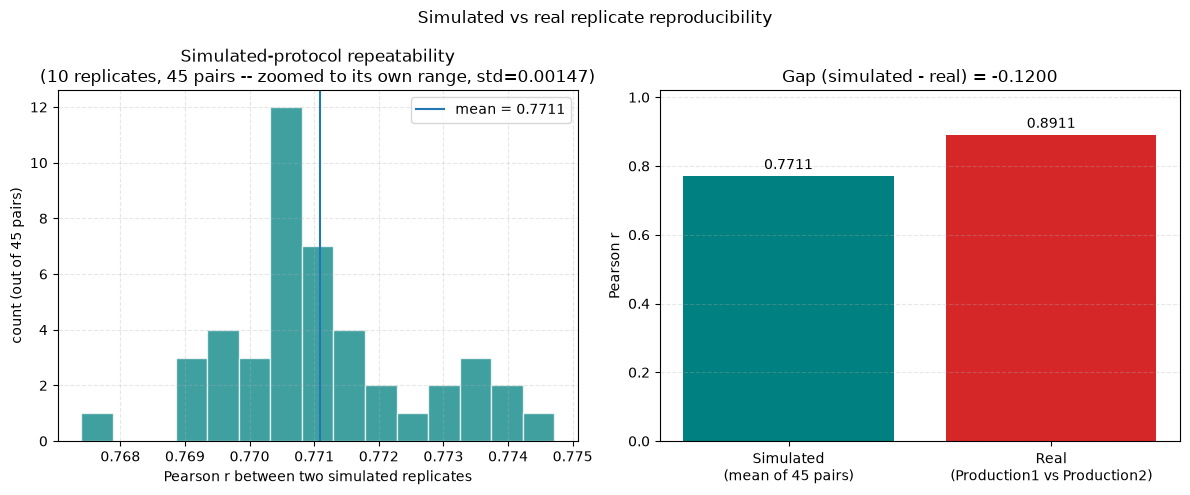

Simulated pairwise r: min=0.7674  mean=0.7711  max=0.7747  std=0.0015
Real Production1 vs Production2 r = 0.8911
Gap (simulated mean - real) = -0.1200


In [8]:
from itertools import combinations

pairwise_r = [pearson(replicates[i], replicates[j]) for i, j in combinations(range(1, N_REPLICATES + 1), 2)]
pairwise_r = np.array(pairwise_r)

# r_p1_p2_real (section 1b) IS the real Production1-vs-Production2 ceiling -- reused directly
# here instead of a separate hardcoded constant.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.hist(pairwise_r, bins=15, color="teal", alpha=0.75, edgecolor="white")
ax.axvline(pairwise_r.mean(), color="tab:blue", linestyle="-",
           label=f"mean = {pairwise_r.mean():.4f}")
ax.set_xlabel("Pearson r between two simulated replicates")
ax.set_ylabel("count (out of 45 pairs)")
ax.set_title(f"Simulated-protocol repeatability\n({N_REPLICATES} replicates, {len(pairwise_r)} "
             f"pairs -- zoomed to its own range, std={pairwise_r.std():.5f})")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

# A histogram can't show BOTH the simulated cluster's tiny spread AND the real ceiling on one
# shared linear axis (they differ by ~0.10, dozens of times the simulated spread) -- a bar
# comparison instead makes the magnitude gap itself the thing that's readable.
ax2 = axes[1]
bars = ax2.bar(["Simulated\n(mean of 45 pairs)", "Real\n(Production1 vs Production2)"],
                [pairwise_r.mean(), r_p1_p2_real], color=["teal", "tab:red"])
ax2.set_ylim(0, 1.02)
ax2.set_ylabel("Pearson r")
ax2.set_title(f"Gap (simulated - real) = {pairwise_r.mean() - r_p1_p2_real:+.4f}")
ax2.grid(True, axis="y", linestyle="--", alpha=0.3)
for bar, v in zip(bars, [pairwise_r.mean(), r_p1_p2_real]):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.4f}", ha="center", fontsize=10)

fig.suptitle("Simulated vs real replicate reproducibility")
fig.tight_layout()
plt.show()

print(f"Simulated pairwise r: min={pairwise_r.min():.4f}  mean={pairwise_r.mean():.4f}  "
      f"max={pairwise_r.max():.4f}  std={pairwise_r.std():.4f}")
print(f"Real Production1 vs Production2 r = {r_p1_p2_real:.4f}")
print(f"Gap (simulated mean - real) = {pairwise_r.mean() - r_p1_p2_real:+.4f}")


# Adding Noise to match the real pearson correlation between same experiences

In [9]:
F_potts = load_F_viab_aav9_potts()
J_potts = load_J_viab_aav9_potts()

F_sel = jnp.zeros_like(F_potts)
J_sel = jnp.zeros_like(J_potts)

key              = jax.random.key(143)
RHO_REF          = 1e-3
MU_FIXED         = 50
T_VIAB_FIXED     = 1.3
NOISE_VIAB_FIXED = 4
D_FIXED          = 1e9
DILUTION_FACTOR  = 1e6
T_SEL_FIXED      = 1.0   # unused by target1, kept at the project default
eps              = 1

N1_FIXED = MU_FIXED * d0 / RHO_REF
N0_FIXED = N1_FIXED * 150

protocol = ProtocolV3(multinomialNGS=True, key=key, N0=N0_FIXED, N1=N1_FIXED,
        dilution_factor=DILUTION_FACTOR, sequences=sequences, D=D_FIXED,
        F_viab=F_potts, J_viab=J_potts, F_sel=F_sel, J_sel=J_sel,
        noise_viab=NOISE_VIAB_FIXED, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED,
        )

print(f"mu = {protocol._rho * protocol.N1 / d0:.2f}   N1={N1_FIXED:.3e}   N0={N0_FIXED:.3e}")
print(f"D/d0 (reads/sequence) = {D_FIXED / d0:.1f}")

mu = 50.00   N1=3.723e+09   N0=5.585e+11
D/d0 (reads/sequence) = 13429.3


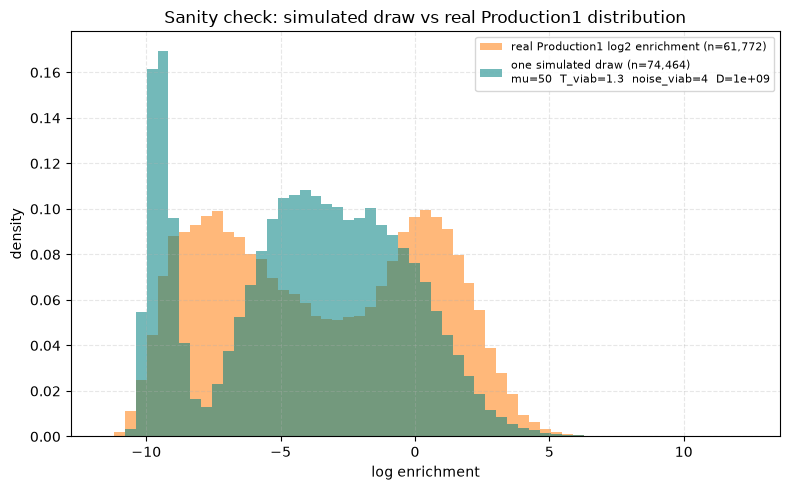

real Production1:   mean=-3.525  std=4.000
simulated preview:  mean=-4.158  std=3.606


In [10]:
preview_run = viability_target1(protocol, key)

p1_valid_only = np.isfinite(p1) & (p1 > 0)
log2_p1_preview = np.log2(p1[p1_valid_only])

fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(min(log2_p1_preview.min(), preview_run.min()),
                    max(log2_p1_preview.max(), preview_run.max()), 60)
ax.hist(log2_p1_preview, bins=bins, alpha=0.55, density=True, color="tab:orange",
        label=f"real Production1 log2 enrichment (n={len(log2_p1_preview):,})")
ax.hist(preview_run, bins=bins, alpha=0.55, density=True, color="teal",
        label=f"one simulated draw (n={len(preview_run):,})\n"
              f"mu={MU_FIXED:.3g}  T_viab={T_VIAB_FIXED:.3g}  noise_viab={NOISE_VIAB_FIXED:.3g}  D={D_FIXED:.3g}")
ax.set_xlabel("log enrichment")
ax.set_ylabel("density")
ax.set_title("Sanity check: simulated draw vs real Production1 distribution")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"real Production1:   mean={log2_p1_preview.mean():+.3f}  std={log2_p1_preview.std():.3f}")
print(f"simulated preview:  mean={preview_run.mean():+.3f}  std={preview_run.std():.3f}")


In [11]:
N_REPLICATES = 5
keys = jax.random.split(jax.random.key(13), N_REPLICATES)  # one subkey per replicate
replicates = {}
for i in range(1, N_REPLICATES + 1):
    replicates[i] = viability_target1(protocol, keys[i - 1])  # keys is 0-indexed
    print(f"replicate_{i}: mean={replicates[i].mean():+.3f}  std={replicates[i].std():.3f}")


replicate_1: mean=-4.146  std=3.628


replicate_2: mean=-4.120  std=3.627


replicate_3: mean=-4.230  std=3.565


replicate_4: mean=-4.104  std=3.623


replicate_5: mean=-4.119  std=3.627


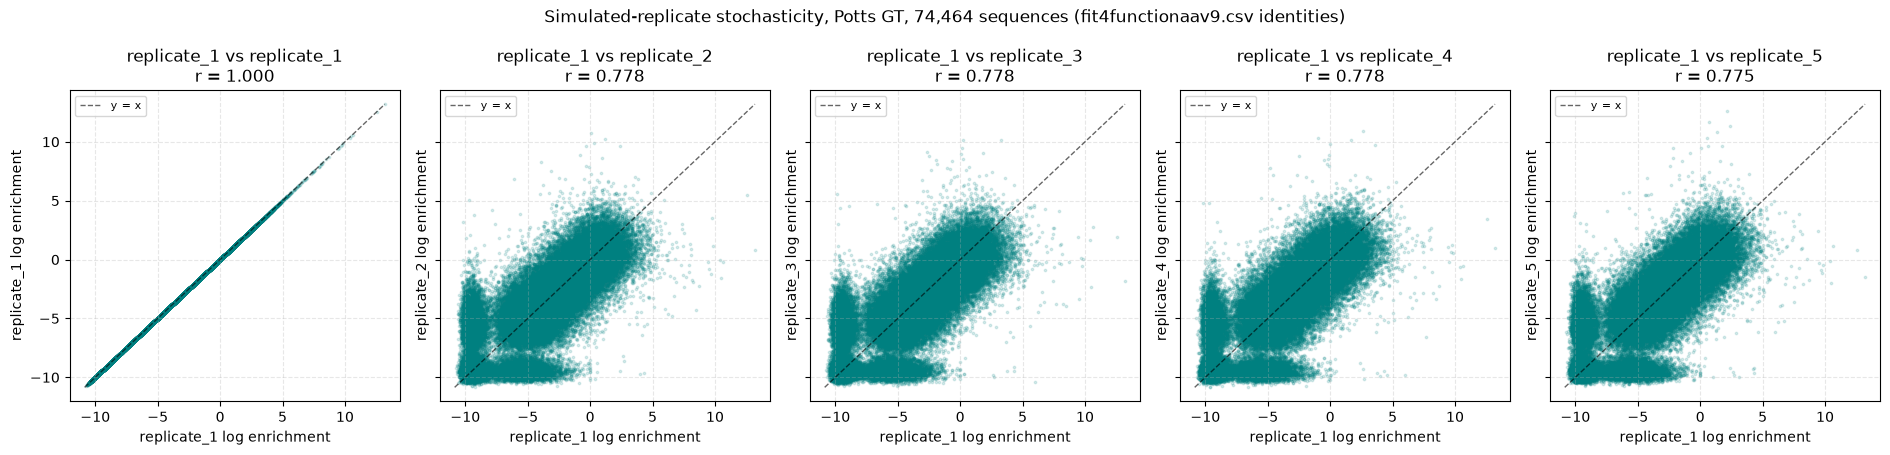

In [12]:
fig, axes = plt.subplots(1, N_REPLICATES, figsize=(19, 4.6), sharex=True, sharey=True)
lo = min(v.min() for v in replicates.values())
hi = max(v.max() for v in replicates.values())

for ax, i in zip(axes, range(1, N_REPLICATES + 1)):
    r_i = pearson(replicates[1], replicates[i])
    ax.scatter(replicates[1], replicates[i], s=3, alpha=0.15, color="teal")
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6, label="y = x")
    ax.set_xlabel("replicate_1 log enrichment")
    ax.set_ylabel(f"replicate_{i} log enrichment")
    ax.set_title(f"replicate_1 vs replicate_{i}\nr = {r_i:.3f}")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle(f"Simulated-replicate stochasticity, Potts GT, {d0:,} sequences (fit4functionaav9.csv identities)")
fig.tight_layout()
plt.show()

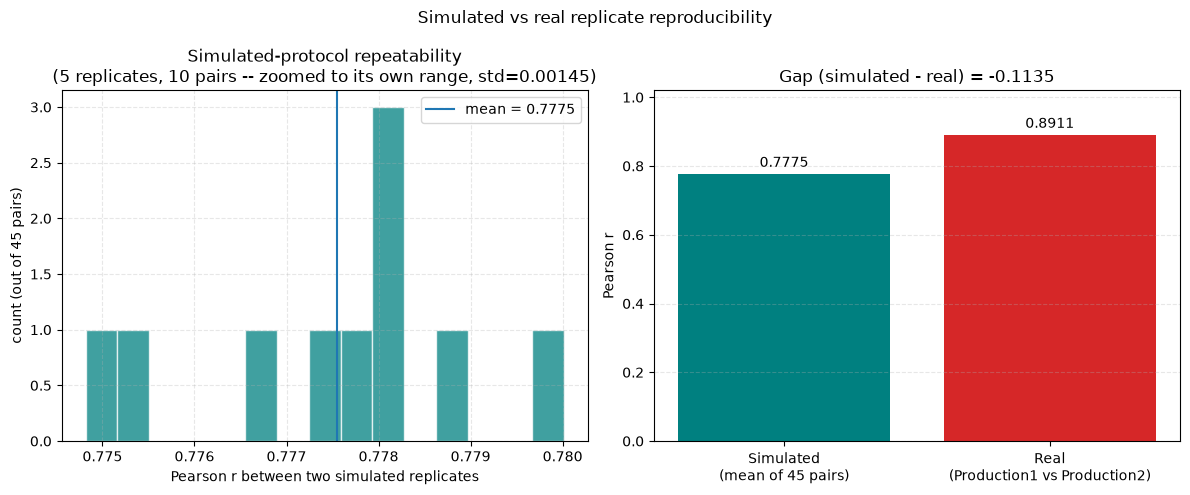

Simulated pairwise r: min=0.7748  mean=0.7775  max=0.7800  std=0.0014
Real Production1 vs Production2 r = 0.8911
Gap (simulated mean - real) = -0.1135


In [13]:
from itertools import combinations

pairwise_r = [pearson(replicates[i], replicates[j]) for i, j in combinations(range(1, N_REPLICATES + 1), 2)]
pairwise_r = np.array(pairwise_r)

# r_p1_p2_real (section 1b) IS the real Production1-vs-Production2 ceiling -- reused directly
# here instead of a separate hardcoded constant.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.hist(pairwise_r, bins=15, color="teal", alpha=0.75, edgecolor="white")
ax.axvline(pairwise_r.mean(), color="tab:blue", linestyle="-",
           label=f"mean = {pairwise_r.mean():.4f}")
ax.set_xlabel("Pearson r between two simulated replicates")
ax.set_ylabel("count (out of 45 pairs)")
ax.set_title(f"Simulated-protocol repeatability\n({N_REPLICATES} replicates, {len(pairwise_r)} "
             f"pairs -- zoomed to its own range, std={pairwise_r.std():.5f})")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

# A histogram can't show BOTH the simulated cluster's tiny spread AND the real ceiling on one
# shared linear axis (they differ by ~0.10, dozens of times the simulated spread) -- a bar
# comparison instead makes the magnitude gap itself the thing that's readable.
ax2 = axes[1]
bars = ax2.bar(["Simulated\n(mean of 45 pairs)", "Real\n(Production1 vs Production2)"],
                [pairwise_r.mean(), r_p1_p2_real], color=["teal", "tab:red"])
ax2.set_ylim(0, 1.02)
ax2.set_ylabel("Pearson r")
ax2.set_title(f"Gap (simulated - real) = {pairwise_r.mean() - r_p1_p2_real:+.4f}")
ax2.grid(True, axis="y", linestyle="--", alpha=0.3)
for bar, v in zip(bars, [pairwise_r.mean(), r_p1_p2_real]):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.4f}", ha="center", fontsize=10)

fig.suptitle("Simulated vs real replicate reproducibility")
fig.tight_layout()
plt.show()

print(f"Simulated pairwise r: min={pairwise_r.min():.4f}  mean={pairwise_r.mean():.4f}  "
      f"max={pairwise_r.max():.4f}  std={pairwise_r.std():.4f}")
print(f"Real Production1 vs Production2 r = {r_p1_p2_real:.4f}")
print(f"Gap (simulated mean - real) = {pairwise_r.mean() - r_p1_p2_real:+.4f}")


# Part 3 -- successively adding cross-packaging and hallucination noise sources

The "Adding Noise" section above found that cranking `noise_viab` from the project's
established "realistic" value (0.5) up to 4 brings the simulated pairwise r down to ~0.86,
close to the real ceiling (`r_p1_p2_real` = 0.891) -- but that tunes an EXISTING noise term to
an arbitrary, non-principled value picked purely to match this one number. This part asks a
different question: starting from the ORIGINAL baseline (`noise_viab=0.5`, same as sections
2-5), does layering in the two OTHER, mechanistically-motivated noise sources already
implemented in `lib/cross_packaging_draft.py` close the gap on their own, without touching
`noise_viab` at all?

- **Cross-packaging** (`ProtocolCrossPackagingBackground`) -- a non-viable variant
  co-transfected with a functional neighbor in the same HEK cell can erroneously package that
  neighbor's DNA, modeled as an aggregate leakage term on `produce_capsids()`'s Poisson rate.
- **Hallucination** (`ProtocolWithHallucination`, via `ProtocolCrossPackagingAndHallucination`
  which combines both) -- PCR/synthesis errors that make the sequenced DNA drift from the
  designed variant, at `AAV9_cross_packaging_and_hallucination_impact.ipynb`'s empirical rate.

Three configs, otherwise IDENTICAL baseline hyperparameters (`mu=50`, `T_viab=1.3`,
`noise_viab=0.5`, `D=1e9`) -- `noise_viab` is deliberately NOT changed here, so any movement in
the pairwise-r gap is attributable only to the added mechanism:
1. **Baseline** `ProtocolV3` (no cross-packaging, no hallucination).
2. **+ cross-packaging** (`cross_packaging_rate=0.05`, same illustration value as
   `AAV9_potts_GT_fitting_protocol.ipynb` section 8).
3. **+ cross-packaging + hallucination** (`hallucination_rate=69/74464`, the empirical rate
   from `new_variant_appearance_analysis.ipynb`).

5 replicates per config (same `N_REPLICATES` as the "Adding Noise" section above), so the
3 new bars are directly comparable to it.

### 3b. Summary: all configs vs the real replicate ceiling

In [14]:
from cross_packaging_draft import ProtocolCrossPackagingBackground, ProtocolCrossPackagingAndHallucination

CROSS_PACKAGING_RATE = 0.05
HALLUCINATION_RATE   = 476 / 74_464 # 476 is the number of variants that are absents in one the
                                    # experiment and has a difference of counts superior to 99% 
                                    # of valid variants (no counts of 0)
N_REPLICATES_P3      = 5   # same as the "Adding Noise" section above, for a direct comparison
key                  = jax.random.key(176525)

# noise_viab hardcoded to 0.5 here (NOT the global NOISE_VIAB_FIXED, currently 4 from the
# "Adding Noise" section above) -- the whole point of this part is to hold it at the original
# baseline and vary only the noise MECHANISM.
BASE_KWARGS_P3 = dict(
    multinomialNGS=True, key=key, N0=N0_FIXED, N1=N1_FIXED, dilution_factor=DILUTION_FACTOR,
    sequences=sequences, D=D_FIXED, F_viab=F_potts, J_viab=J_potts, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.5, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED,
)

variants_p3 = {
    "baseline (noise_viab=0.5)": ProtocolV3(**BASE_KWARGS_P3),
    "+ cross-packaging": ProtocolCrossPackagingBackground(
        **BASE_KWARGS_P3, cross_packaging_rate=CROSS_PACKAGING_RATE),
    "+ cross-packaging + hallucination": ProtocolCrossPackagingAndHallucination(
        **BASE_KWARGS_P3, cross_packaging_rate=CROSS_PACKAGING_RATE,
        hallucination=True, hallucination_rate=HALLUCINATION_RATE),
}

# Same base `key` for every protocol (via BASE_KWARGS_P3), but each of the N_REPLICATES_P3
# replicate draws needs its OWN subkey: viability_target1 sets protocol.key before each
# loop_DE() call, and loop_DE() is fully deterministic given that key -- reusing one key gives
# 5 byte-identical replicates (mean pairwise r = 1.0000). Split once and reuse the same 5
# subkeys across the 3 configs, so the configs are compared on identical stochastic draws.
rep_keys_p3 = jax.random.split(key, N_REPLICATES_P3)

results_p3 = {}
for name, proto in variants_p3.items():
    reps = [viability_target1(proto, rep_keys_p3[r]) for r in range(N_REPLICATES_P3)]
    pairs_r = np.array([pearson(reps[i], reps[j]) for i, j in combinations(range(N_REPLICATES_P3), 2)])
    results_p3[name] = dict(replicates=reps, pairwise_r=pairs_r)
    print(f"{name:34s}  mean pairwise r = {pairs_r.mean():.4f}  "
          f"(gap vs real = {pairs_r.mean() - r_p1_p2_real:+.4f})")


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

baseline (noise_viab=0.5)           mean pairwise r = 0.7699  (gap vs real = -0.1212)


+ cross-packaging                   mean pairwise r = 0.7586  (gap vs real = -0.1325)


+ cross-packaging + hallucination   mean pairwise r = 0.7464  (gap vs real = -0.1446)


### 3a. Per-config replicate scatter, i in [1, 5]

Same "replicate_1 as fixed x-axis" panels as section 4 and the "Adding Noise" section above,
now for each of the 3 Part 3 configs -- one row per config, one column per replicate index
(all 5, not just the first 4).

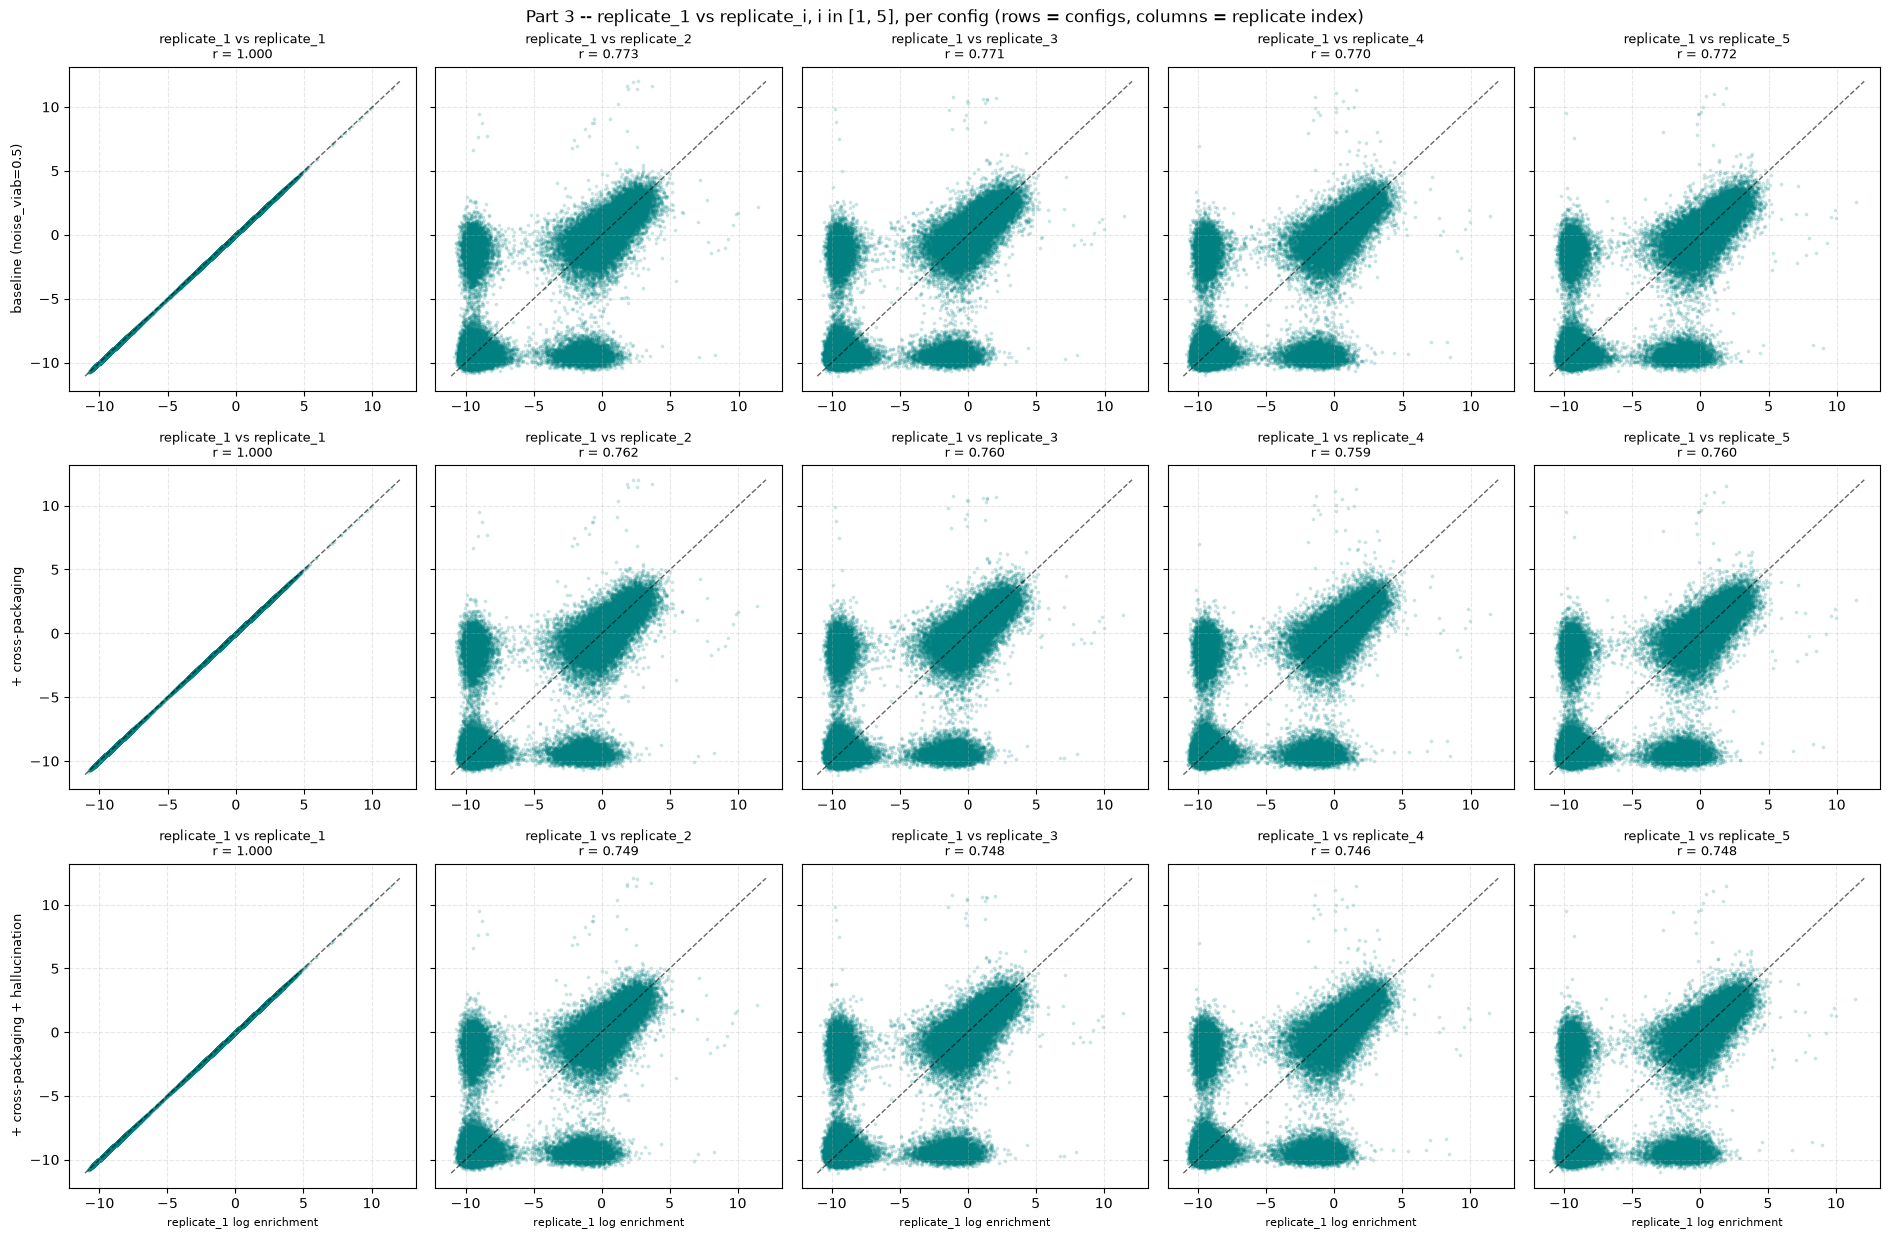

In [15]:
fig, axes = plt.subplots(len(results_p3), N_REPLICATES_P3, figsize=(19, 4.2 * len(results_p3)),
                          sharex="row", sharey="row")
for row, (name, res) in enumerate(results_p3.items()):
    reps = res["replicates"]
    lo = min(r.min() for r in reps)
    hi = max(r.max() for r in reps)
    for col in range(N_REPLICATES_P3):
        ax = axes[row, col]
        r_i = pearson(reps[0], reps[col])
        ax.scatter(reps[0], reps[col], s=3, alpha=0.15, color="teal")
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6)
        ax.set_title(f"replicate_1 vs replicate_{col + 1}\nr = {r_i:.3f}", fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.3)
        if col == 0:
            ax.set_ylabel(name, fontsize=9)
        if row == len(results_p3) - 1:
            ax.set_xlabel("replicate_1 log enrichment", fontsize=8)

fig.suptitle(f"Part 3 -- replicate_1 vs replicate_i, i in [1, {N_REPLICATES_P3}], per config "
             "(rows = configs, columns = replicate index)")
fig.tight_layout()
plt.show()

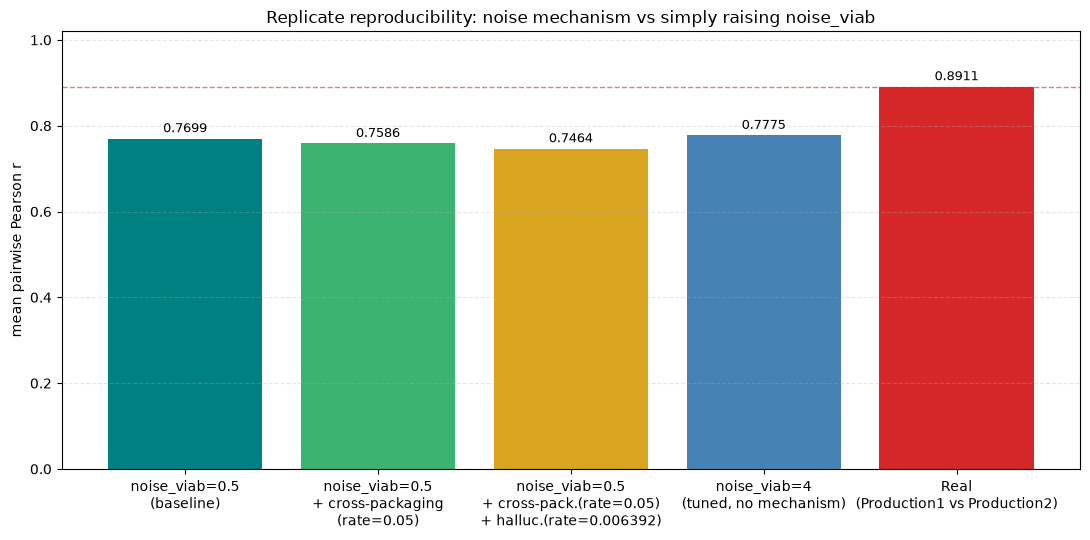

Gap vs real (r_p1_p2_real = 0.8911), mean pairwise r per config:
  noise_viab=0.5 (baseline)                     r=0.7699  gap=-0.1212
  noise_viab=0.5 + cross-packaging (rate=0.05)  r=0.7586  gap=-0.1325
  noise_viab=0.5 + cross-pack.(rate=0.05) + halluc.(rate=0.006392) r=0.7464  gap=-0.1446
  noise_viab=4 (tuned, no mechanism)            r=0.7775  gap=-0.1135


In [16]:
# `pairwise_r` here is still whatever the "Adding Noise" section above last computed
# (noise_viab=4, 5 replicates) -- captured explicitly under its own name to avoid ambiguity.
noise_viab_4_pairwise_r = pairwise_r.copy()

all_configs = {
    f"noise_viab={BASE_KWARGS_P3['noise_viab']}\n(baseline)":
        results_p3["baseline (noise_viab=0.5)"]["pairwise_r"],
    f"noise_viab={BASE_KWARGS_P3['noise_viab']}\n+ cross-packaging\n(rate={CROSS_PACKAGING_RATE:.3g})":
        results_p3["+ cross-packaging"]["pairwise_r"],
    f"noise_viab={BASE_KWARGS_P3['noise_viab']}\n+ cross-pack.(rate={CROSS_PACKAGING_RATE:.3g})\n"
    f"+ halluc.(rate={HALLUCINATION_RATE:.4g})":
        results_p3["+ cross-packaging + hallucination"]["pairwise_r"],
    f"noise_viab={NOISE_VIAB_FIXED}\n(tuned, no mechanism)": noise_viab_4_pairwise_r,
}

fig, ax = plt.subplots(figsize=(11, 5.5))
names   = list(all_configs.keys()) + ["Real\n(Production1 vs Production2)"]
means   = [v.mean() for v in all_configs.values()] + [r_p1_p2_real]
colors  = ["teal", "mediumseagreen", "goldenrod", "steelblue", "tab:red"]

bars = ax.bar(names, means, color=colors)
ax.axhline(r_p1_p2_real, color="tab:red", linestyle="--", alpha=0.6, lw=1)
ax.set_ylim(0, 1.02)
ax.set_ylabel("mean pairwise Pearson r")
ax.set_title("Replicate reproducibility: noise mechanism vs simply raising noise_viab")
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.4f}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()

print("Gap vs real (r_p1_p2_real = "
      f"{r_p1_p2_real:.4f}), mean pairwise r per config:")
for name, vals in all_configs.items():
    print(f"  {name.replace(chr(10), ' '):45s} r={vals.mean():.4f}  gap={vals.mean() - r_p1_p2_real:+.4f}")

In [17]:
from cross_packaging_draft import ProtocolCrossPackagingBackground, ProtocolCrossPackagingAndHallucination

CROSS_PACKAGING_RATE = 0.05
HALLUCINATION_RATE   = 67 / 74_464 # 476 is the number of variants that are absents in one the
                                    # experiment and has a difference of counts superior to 99% 
                                    # of valid variants (no counts of 0)
N_REPLICATES_P3      = 5   # same as the "Adding Noise" section above, for a direct comparison
key                  = jax.random.key(6309724)
# noise_viab hardcoded to 0.5 here (NOT the global NOISE_VIAB_FIXED, currently 4 from the
# "Adding Noise" section above) -- the whole point of this part is to hold it at the original
# baseline and vary only the noise MECHANISM.
BASE_KWARGS_P3 = dict(
    multinomialNGS=True, key=key, N0=N0_FIXED, N1=N1_FIXED, dilution_factor=DILUTION_FACTOR,
    sequences=sequences, D=D_FIXED, F_viab=F_potts, J_viab=J_potts, F_sel=F_sel, J_sel=J_sel,
    noise_viab=3, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED,
)

variants_p3 = {
    "baseline (noise_viab=0.5)": ProtocolV3(**BASE_KWARGS_P3),
    "+ cross-packaging": ProtocolCrossPackagingBackground(
        **BASE_KWARGS_P3, cross_packaging_rate=CROSS_PACKAGING_RATE),
    "+ cross-packaging + hallucination": ProtocolCrossPackagingAndHallucination(
        **BASE_KWARGS_P3, cross_packaging_rate=CROSS_PACKAGING_RATE,
        hallucination=True, hallucination_rate=HALLUCINATION_RATE),
}

# Same base `key` for every protocol (via BASE_KWARGS_P3), but each of the N_REPLICATES_P3
# replicate draws needs its OWN subkey -- see the note in section 3b: reusing one key gives
# 5 byte-identical replicates. Same 5 subkeys reused across the 3 configs (paired comparison).
rep_keys_p3 = jax.random.split(key, N_REPLICATES_P3)

results_p3 = {}
for name, proto in variants_p3.items():
    reps = [viability_target1(proto, rep_keys_p3[r]) for r in range(N_REPLICATES_P3)]
    pairs_r = np.array([pearson(reps[i], reps[j]) for i, j in combinations(range(N_REPLICATES_P3), 2)])
    results_p3[name] = dict(replicates=reps, pairwise_r=pairs_r)
    print(f"{name:34s}  mean pairwise r = {pairs_r.mean():.4f}  "
          f"(gap vs real = {pairs_r.mean() - r_p1_p2_real:+.4f})")


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

baseline (noise_viab=0.5)           mean pairwise r = 0.7880  (gap vs real = -0.1031)


+ cross-packaging                   mean pairwise r = 0.7555  (gap vs real = -0.1356)


+ cross-packaging + hallucination   mean pairwise r = 0.7541  (gap vs real = -0.1369)


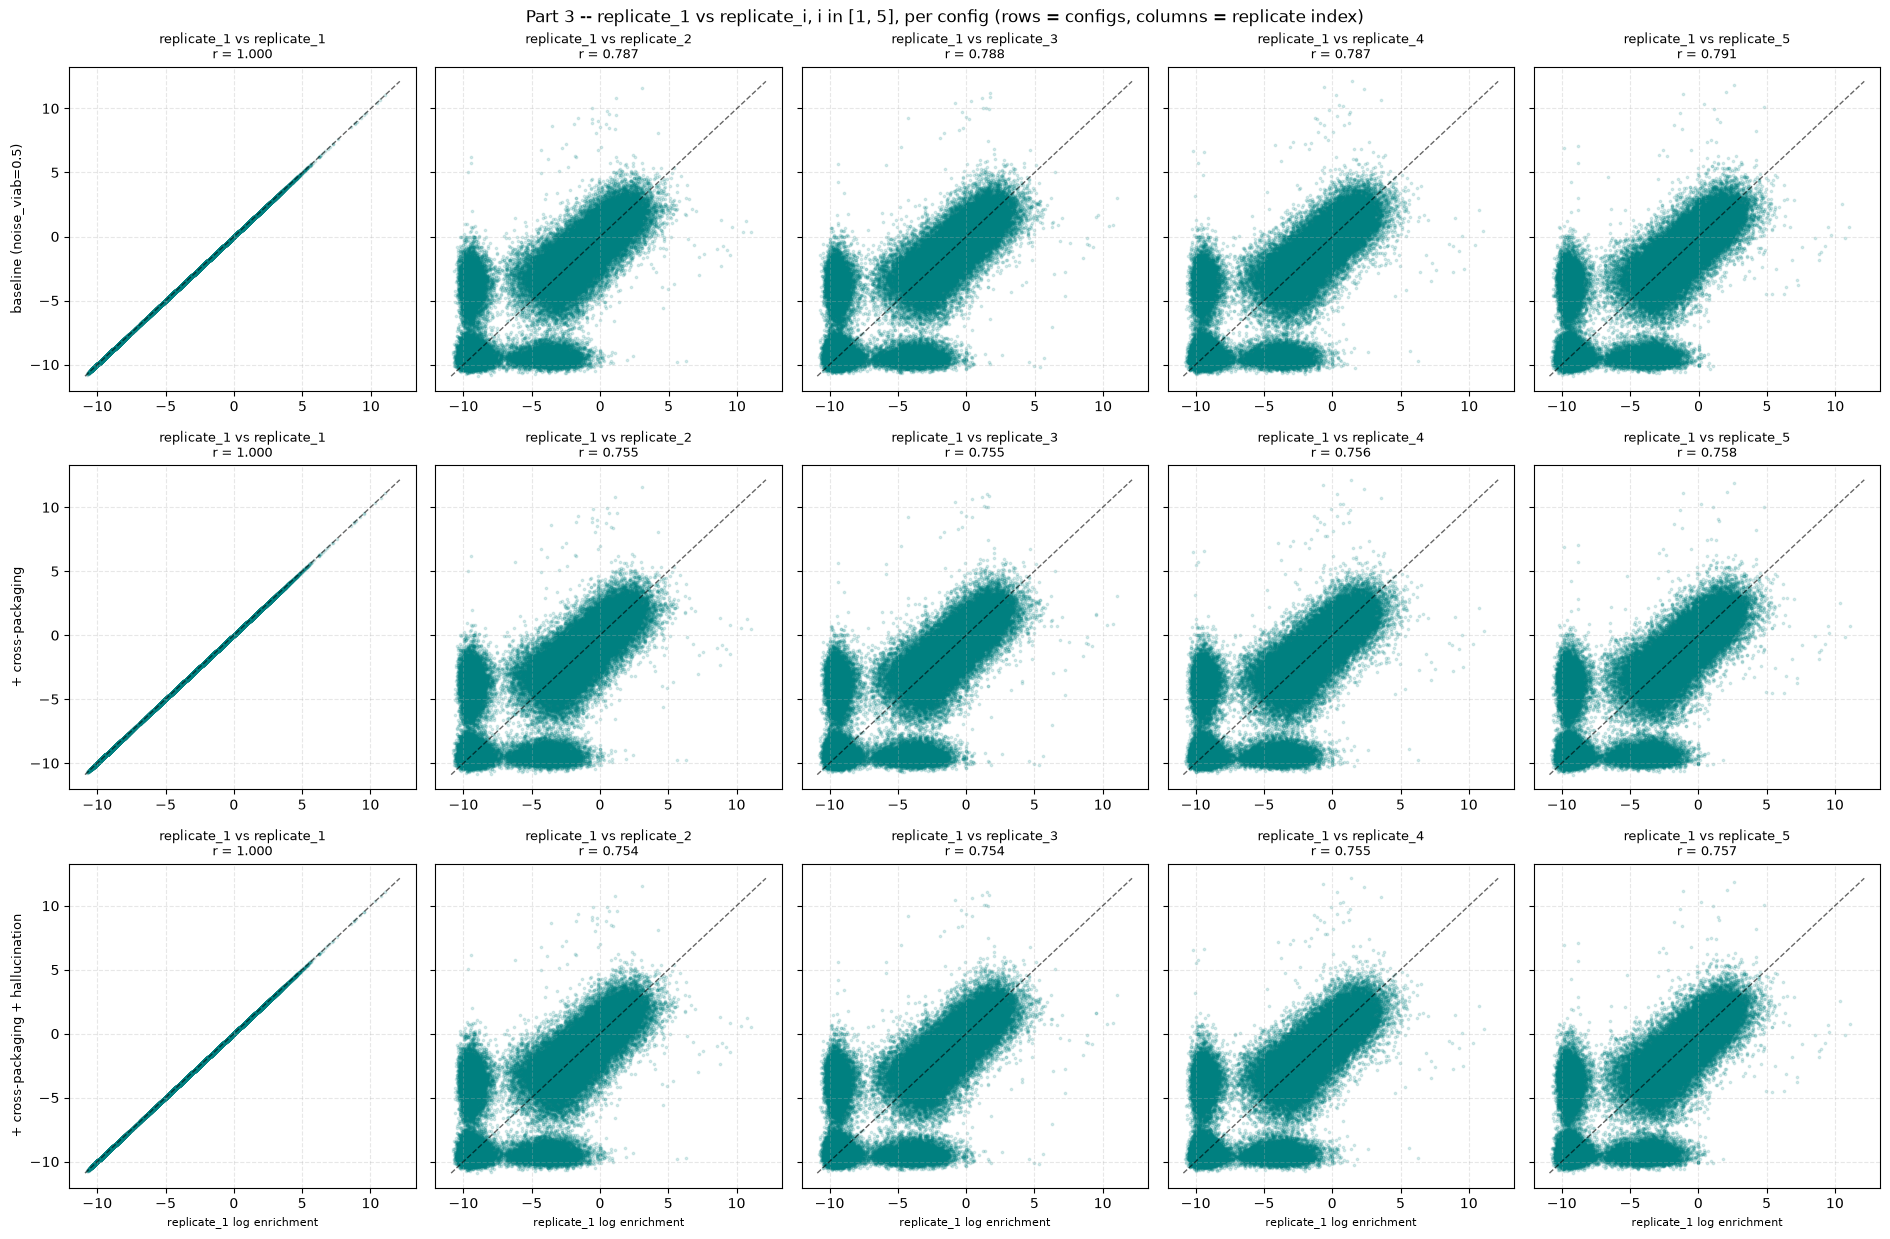

In [18]:
fig, axes = plt.subplots(len(results_p3), N_REPLICATES_P3, figsize=(19, 4.2 * len(results_p3)),
                          sharex="row", sharey="row")
for row, (name, res) in enumerate(results_p3.items()):
    reps = res["replicates"]
    lo = min(r.min() for r in reps)
    hi = max(r.max() for r in reps)
    for col in range(N_REPLICATES_P3):
        ax = axes[row, col]
        r_i = pearson(reps[0], reps[col])
        ax.scatter(reps[0], reps[col], s=3, alpha=0.15, color="teal")
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6)
        ax.set_title(f"replicate_1 vs replicate_{col + 1}\nr = {r_i:.3f}", fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.3)
        if col == 0:
            ax.set_ylabel(name, fontsize=9)
        if row == len(results_p3) - 1:
            ax.set_xlabel("replicate_1 log enrichment", fontsize=8)

fig.suptitle(f"Part 3 -- replicate_1 vs replicate_i, i in [1, {N_REPLICATES_P3}], per config "
             "(rows = configs, columns = replicate index)")
fig.tight_layout()
plt.show()

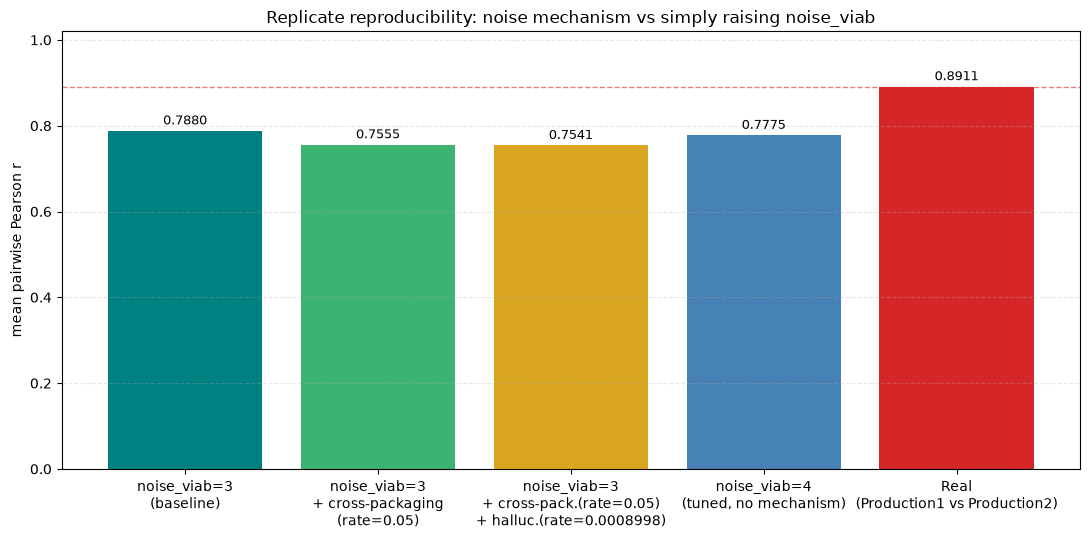

Gap vs real (r_p1_p2_real = 0.8911), mean pairwise r per config:
  noise_viab=3 (baseline)                       r=0.7880  gap=-0.1031
  noise_viab=3 + cross-packaging (rate=0.05)    r=0.7555  gap=-0.1356
  noise_viab=3 + cross-pack.(rate=0.05) + halluc.(rate=0.0008998) r=0.7541  gap=-0.1369
  noise_viab=4 (tuned, no mechanism)            r=0.7775  gap=-0.1135


In [19]:
# `pairwise_r` here is still whatever the "Adding Noise" section above last computed
# (noise_viab=4, 5 replicates) -- captured explicitly under its own name to avoid ambiguity.
noise_viab_4_pairwise_r = pairwise_r.copy()

all_configs = {
    f"noise_viab={BASE_KWARGS_P3['noise_viab']}\n(baseline)":
        results_p3["baseline (noise_viab=0.5)"]["pairwise_r"],
    f"noise_viab={BASE_KWARGS_P3['noise_viab']}\n+ cross-packaging\n(rate={CROSS_PACKAGING_RATE:.3g})":
        results_p3["+ cross-packaging"]["pairwise_r"],
    f"noise_viab={BASE_KWARGS_P3['noise_viab']}\n+ cross-pack.(rate={CROSS_PACKAGING_RATE:.3g})\n"
    f"+ halluc.(rate={HALLUCINATION_RATE:.4g})":
        results_p3["+ cross-packaging + hallucination"]["pairwise_r"],
    f"noise_viab={NOISE_VIAB_FIXED}\n(tuned, no mechanism)": noise_viab_4_pairwise_r,
}

fig, ax = plt.subplots(figsize=(11, 5.5))
names   = list(all_configs.keys()) + ["Real\n(Production1 vs Production2)"]
means   = [v.mean() for v in all_configs.values()] + [r_p1_p2_real]
colors  = ["teal", "mediumseagreen", "goldenrod", "steelblue", "tab:red"]

bars = ax.bar(names, means, color=colors)
ax.axhline(r_p1_p2_real, color="tab:red", linestyle="--", alpha=0.6, lw=1)
ax.set_ylim(0, 1.02)
ax.set_ylabel("mean pairwise Pearson r")
ax.set_title("Replicate reproducibility: noise mechanism vs simply raising noise_viab")
ax.grid(True, axis="y", linestyle="--", alpha=0.3)
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.4f}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()

print("Gap vs real (r_p1_p2_real = "
      f"{r_p1_p2_real:.4f}), mean pairwise r per config:")
for name, vals in all_configs.items():
    print(f"  {name.replace(chr(10), ' '):45s} r={vals.mean():.4f}  gap={vals.mean() - r_p1_p2_real:+.4f}")

## Part 3c -- sanity-check the hallucination encoding

Worry: two protocol instances should hallucinate *different* variants, and if the pairwise `r`
barely drops when hallucination is on, maybe it isn't actually wired in.

What the code does (`cross_packaging_draft.LambdaWithHallucination.sequence_reads`): it does
**not** sample new sequences from the 20**7 space. It keeps the fixed `d0` = 74,464 designed
sequences and, at every NGS checkpoint, draws an independent `Bernoulli(hallucination_rate)`
per sequence; the ~`rate * d0` that come up True get a spurious `Poisson(D / d0)` read count
added on top of their real reads. So "new variant appearance" = an existing designed variant
reading at fit-level in one run and ~0 in another -- exactly what
`new_variant_appearance_analysis.ipynb` flagged (a designed variant that's 0 in one replicate,
clearly fit in the other; hypothesis: a PCR/synthesis error detaches one codon construct's DNA
from its designed sequence).

Two checks below, run against the **real** `ProtocolWithHallucination` (nothing reimplemented
-- the `(d0,)`-shaped `jax.random.bernoulli` is the only bernoulli call anywhere in this
pipeline, so intercepting it captures exactly the hallucination mask):

1. **Different subsets between runs** -- two draws with different keys hallucinate near-disjoint
   index sets, overlap ~ chance (`d0 * rate**2`).
2. **Why `r` barely moves** -- that subset is ~0.1-0.6 % of 74,464 points; dropping every
   ever-hallucinated sequence lifts `r` by a rounding error. Crank the rate 20x and `r` does
   fall -> the mechanism propagates, the empirical rate is just too low to register on a
   global Pearson. The effect lives in the tail (count of discordant zeros), not in `r`.

In [20]:
import cross_packaging_draft as cpd

HALLUCINATION_RATE_CHECK = 476 / 74_464           # same value as the first cell of section 3b
CHECKPOINTS              = ["lambda0p", "lambda2p", "lambda3p"]

_HALLUC_KWARGS = dict(
    multinomialNGS=True, N0=N0_FIXED, N1=N1_FIXED, dilution_factor=DILUTION_FACTOR,
    sequences=sequences, D=D_FIXED, F_viab=F_potts, J_viab=J_potts, F_sel=F_sel, J_sel=J_sel,
    noise_viab=0.5, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED,
    hallucination=True, hallucination_rate=HALLUCINATION_RATE_CHECK,
)


def hallucinated_draw(draw_key, **overrides):
    """One viability_target1 draw through the real cpd.ProtocolWithHallucination, capturing
    the per-checkpoint hallucination mask by spying on the (d0,)-shaped jax.random.bernoulli
    call -- the ONLY bernoulli call in this pipeline (sample_sequences->binomial,
    produce_capsids/selectivity->normal+poisson, CFU amplification deterministic).
    Returns (target1, [hallucinated_index_array per NGS checkpoint])."""
    proto = cpd.ProtocolWithHallucination(key=draw_key, **{**_HALLUC_KWARGS, **overrides})
    hits, orig = [], jax.random.bernoulli

    def spy(k, p=0.5, shape=None):
        out = orig(k, p, shape)
        if shape == (proto.d0,):
            hits.append(np.flatnonzero(np.asarray(out)))
        return out

    jax.random.bernoulli = spy
    try:
        target1 = viability_target1(proto, draw_key)
    finally:
        jax.random.bernoulli = orig
    return target1, hits


t1_A, hits_A = hallucinated_draw(jax.random.key(101))
t1_B, hits_B = hallucinated_draw(jax.random.key(202))

print(f"hallucination_rate = {HALLUCINATION_RATE_CHECK:.5f}  ->  ~{HALLUCINATION_RATE_CHECK * d0:.0f} "
      f"hallucinated / {d0:,} designed sequences per checkpoint\n")
for cp, a, b in zip(CHECKPOINTS, hits_A, hits_B):
    shared = np.intersect1d(a, b)
    print(f"  {cp:9s}  A={len(a):4d}  B={len(b):4d}  shared={len(shared):3d}  "
          f"(expected if independent ~ {len(a) * len(b) / d0:.1f})")

uA = np.unique(np.concatenate(hits_A))
uB = np.unique(np.concatenate(hits_B))
shared = np.intersect1d(uA, uB)
print(f"\n  union over the 3 checkpoints:  A={len(uA)}  B={len(uB)}  shared={len(shared)}  "
      f"(expected if independent ~ {len(uA) * len(uB) / d0:.1f})   Jaccard={len(shared) / len(np.union1d(uA, uB)):.4f}")

print("\n  hallucinated AA sequences at lambda2p -- run A vs run B (first 10 each):")
for idx in hits_A[1][:10]:
    print(f"    A  seq {int(idx):6d}   {df['AA'].iloc[int(idx)]}")
for idx in hits_B[1][:10]:
    print(f"    B  seq {int(idx):6d}   {df['AA'].iloc[int(idx)]}")


hallucination_rate = 0.00639  ->  ~476 hallucinated / 74,464 designed sequences per checkpoint

  lambda0p   A= 471  B= 473  shared=  2  (expected if independent ~ 3.0)
  lambda2p   A= 447  B= 484  shared=  2  (expected if independent ~ 2.9)
  lambda3p   A= 493  B= 464  shared=  0  (expected if independent ~ 3.1)

  union over the 3 checkpoints:  A=1403  B=1412  shared=20  (expected if independent ~ 26.6)   Jaccard=0.0072

  hallucinated AA sequences at lambda2p -- run A vs run B (first 10 each):
    A  seq    283   ACLIIPH
    A  seq    546   ADYEGGT
    A  seq    589   AEEIFTP
    A  seq    632   AEKQFCI
    A  seq    988   AGGRAQM
    A  seq   1066   AGQEWCF
    A  seq   1142   AHATYVF
    A  seq   1186   AHFNYHF
    A  seq   1266   AHQQCWA
    A  seq   1366   AIEWCHL
    B  seq     21   AADVATA
    B  seq     27   AAEGDIV
    B  seq    281   ACLETGQ
    B  seq    329   ACQPYIV
    B  seq    336   ACRGMIQ
    B  seq    735   AEYKVEE
    B  seq    753   AFCKICE
    B  seq    986   AG

In [21]:
# --- why the pairwise r barely moves, and proof the mechanism does propagate ---------------
r_all   = pearson(t1_A, t1_B)
touched = np.union1d(uA, uB)                          # every sequence hallucinated in A or B
keep    = np.setdiff1d(np.arange(d0), touched)
print(f"r(A, B)  over all {d0:,} sequences               = {r_all:.4f}")
print(f"r(A, B)  dropping the {len(touched)} ever-hallucinated  = {pearson(t1_A[keep], t1_B[keep]):.4f}  "
      f"(+{pearson(t1_A[keep], t1_B[keep]) - r_all:.4f})")

# the per-sequence effect IS large -- just rare. lambda2p-hallucinated in A but NOT in B:
only_A = np.setdiff1d(hits_A[1], hits_B[1])
print(f"\nfor the {len(only_A)} seqs hallucinated at lambda2p in A only:")
print(f"   mean target1 in A (hallucinated) = {t1_A[only_A].mean():+.2f}")
print(f"   mean target1 in B (not)          = {t1_B[only_A].mean():+.2f}")
print(f"   mean target1 elsewhere           = {t1_A[keep].mean():+.2f}")

# sanity: 20x the rate -> r visibly drops -> mechanism feeds through, empirical rate is just small
t1_hiA, _ = hallucinated_draw(jax.random.key(101), hallucination_rate=0.10)
t1_hiB, _ = hallucinated_draw(jax.random.key(202), hallucination_rate=0.10)
print(f"\nrate = 0.10 (unphysical, sanity only):  r(A, B) = {pearson(t1_hiA, t1_hiB):.4f}")


r(A, B)  over all 74,464 sequences               = 0.7630
r(A, B)  dropping the 2795 ever-hallucinated  = 0.7747  (+0.0118)

for the 445 seqs hallucinated at lambda2p in A only:
   mean target1 in A (hallucinated) = +0.46
   mean target1 in B (not)          = -5.82
   mean target1 elsewhere           = -5.72



rate = 0.10 (unphysical, sanity only):  r(A, B) = 0.6119


# Part 4 -- PCR-mutation noise only: correlation between experiments

Fourth noise source from `lib/cross_packaging_draft.py` -- **PCR-introduced point mutations**
(`ProtocolWithPCRMutations`) -- and **nothing else**: no hallucination, no cross-packaging,
`noise_viab` at the 0.5 baseline.

Each PCR error is a single-amino-acid change of a designed variant, made on a fresh copy
mid-PCR, that then amplifies for every remaining cycle. The pool is extended to `d0_ext` slots
(`[:d0]` designed, `[d0:]` every distinct novel single-mutant 7-mer; `protocol.ext_sequences`
names each slot), so a mutant is a **real measured sequence with its own read count** and two
runs are comparable slot by slot. The mutant molecules never enter the DE-loop's biological
pool -- they exist only in the measurement branch.

### Two things this part has to get right

**1. The PCR must actually amplify.** `dilution_factor` is a **divisor**:
`sample_sequences()` pipettes each molecule with probability `p = 1/dilution_factor`, so a
*larger* value means a *smaller* aliquot. At the notebook's `dilution_factor=10` we pipette
**10 %** of the pool -- ~5.6e10 molecules against `K_MM = 1e6`, giving `p_n(cycle 1) ~ 1.8e-05`:
the 40 cycles multiply the pool by **~1x** and the PCR step is inert. A mutation born in cycle 1
has nothing to amplify into, stays a single molecule (max ~2 reads), and no jackpot is possible
at *any* mutation rate. (That setting is also self-destructive: `_ngs_and_deplete` removes the
aliquot for good, so three checkpoints consume ~27 % of the library just to measure it.)

Part 4 uses `DILUTION_NGS = 1e6` -- one **millionth** of the pool, ~5.6e5 molecules, the drop you
would actually take for a sequencing prep and then amplify:

| | p = 1/df | fraction pipetted | aliquot into PCR | aliquot / `K_MM` | `p_n` (cycle 1) | amplification |
|---|---|---|---|---|---|---|
| `dilution_factor = 10` (rest of notebook) | 0.1 | 10 % | 5.6e10 | 5.6e4 | 1.8e-05 | ~1x (inert) |
| `DILUTION_NGS = 1e6` (here) | 1e-6 | 0.0001 % | 5.6e5 | 0.56 | 0.64 | exponential |

**2. Pearson must be taken over the sequences actually observed.** Of the ~9.9 M extended
slots, all but a few hundred thousand are zero in *every* run; including them drives `r`
mechanically toward 1. The comparison a real analyst makes is over the **union of 7-mers seen
in either NGS run** -- `r_observed` below. `r_designed` (the `[:d0]` block) and the naive
all-slot `r` are reported alongside for contrast.

A novel mutant is absent from the initial pool, so its log2 enrichment is
`log2((reads + eps)/(0 + eps)) = log2(reads)` with `eps = 1` -- a clone read 1000 times scores
10. That same 7-mer is absent from the other experiment and scores 0 there: the maximal
possible disagreement, which is what pulls the correlation down.

Runtime ~5 min (8 s one-time neighbour-map precompute + ~17 s per `loop_DE`, 5 rates x 3
experiments; `pcr_mutation_rate` is a plain attribute so the precompute is not repeated).

In [26]:
import cross_packaging_draft as cpd
from itertools import combinations

DILUTION_NGS = 1e6                             # small NGS aliquot -> the PCR actually amplifies
MUT_RATES    = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]   # 0.0 = in-regime control (same extended pool)
DETAIL_RATE  = 1e-2                            # the rate whose arrays are kept for the plots below
N_EXP_P4     = 3
key_p4       = jax.random.key(717)

BASE_KWARGS_P4 = dict(
    multinomialNGS=True, N0=N0_FIXED, N1=N1_FIXED, dilution_factor=DILUTION_NGS,
    sequences=sequences, D=D_FIXED, F_viab=F_potts, J_viab=J_potts, F_sel=F_sel, J_sel=J_sel,
    noise_viab=5, noise_sel=0.0, T_sel=T_SEL_FIXED, T_viab=T_VIAB_FIXED,
)
proto_p4 = cpd.ProtocolWithPCRMutations(key=key_p4, pcr_mutations=True,
                                        pcr_mutation_rate=0.0, **BASE_KWARGS_P4)
d0_ext   = proto_p4.d0_ext
exp_keys = jax.random.split(key_p4, N_EXP_P4)
pairs_p4 = list(combinations(range(N_EXP_P4), 2))
print(f"d0 = {d0:,}   d0_ext = {d0_ext:,}   ({d0_ext - d0:,} novel single-mutant slots)\n")


def ngs_draw(protocol, k):
    """One experiment -> (lambda0p, lambda2p), both length d0_ext."""
    protocol.lambda0 = jnp.full(protocol.d0, protocol.N0 / protocol.d0)
    protocol.key     = k
    _bio, ngs = protocol.loop_DE()
    return np.asarray(ngs[0]), np.asarray(ngs[1])


sweep_p4, detail_p4 = {}, None
for rate in MUT_RATES:
    proto_p4.pcr_mutation_rate = rate    # plain attribute -> neighbour map is NOT recomputed
    runs = [ngs_draw(proto_p4, exp_keys[e]) for e in range(N_EXP_P4)]
    # log2 enrichment, eps=1: a novel 7-mer absent at lambda0p scores exactly log2(reads)
    t2   = [np.log2((l2 + eps) / (l0 + eps)) for l0, l2 in runs]
    obs  = np.zeros(d0_ext, bool)        # 7-mers ANY run actually observed
    for l0, l2 in runs:
        obs |= (l0 > 0) | (l2 > 0)
    sweep_p4[rate] = dict(
        r_designed = np.array([pearson(t2[i][:d0], t2[j][:d0]) for i, j in pairs_p4]),
        r_observed = np.array([pearson(t2[i][obs], t2[j][obs]) for i, j in pairs_p4]),
        r_allslots = np.array([pearson(t2[i],      t2[j])      for i, j in pairs_p4]),
        n_novel    = [int((l2[d0:] > 0).sum()) for _, l2 in runs],
        novel_frac = float(np.mean([l2[d0:].sum() for _, l2 in runs])) / D_FIXED,
        n_observed = int(obs.sum()),
    )
    if rate == DETAIL_RATE:
        detail_p4 = dict(runs=runs, t2=t2, obs=obs)
    s = sweep_p4[rate]
    print(f"rate={rate:<8g} novel 7-mers/exp={s['n_novel']}  "
          f"novel share of D={100 * s['novel_frac']:5.2f}%  "
          f"r(designed)={s['r_designed'].mean():.4f}  "
          f"r(observed union)={s['r_observed'].mean():.4f}")

d0 = 74,464   d0_ext = 9,939,294   (9,864,830 novel single-mutant slots)



rate=0        novel 7-mers/exp=[0, 0, 0]  novel share of D= 0.00%  r(designed)=0.7359  r(observed union)=0.7359


rate=1e-05    novel 7-mers/exp=[372, 311, 402]  novel share of D= 0.00%  r(designed)=0.7359  r(observed union)=0.7417


rate=0.0001   novel 7-mers/exp=[3078, 2500, 3670]  novel share of D= 0.00%  r(designed)=0.7359  r(observed union)=0.7551


rate=0.001    novel 7-mers/exp=[23644, 16492, 30471]  novel share of D= 0.01%  r(designed)=0.7359  r(observed union)=0.6106


rate=0.01     novel 7-mers/exp=[142010, 104902, 181037]  novel share of D= 0.10%  r(designed)=0.7359  r(observed union)=0.1046


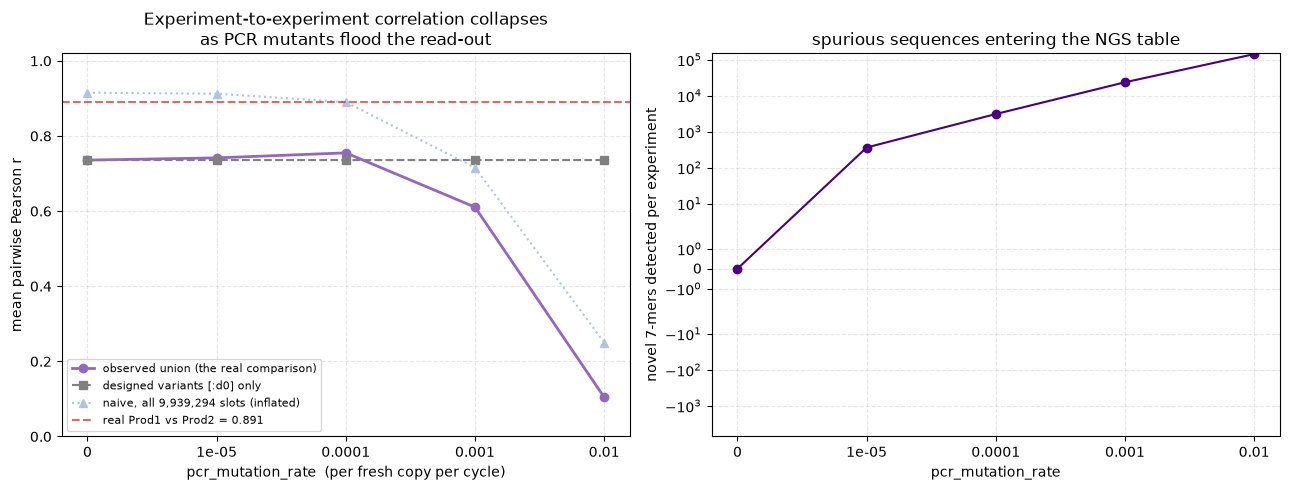

     rate    novel/exp    % of D   r designed   r observed
        0            0     0.00%       0.7359       0.7359
    1e-05          362     0.00%       0.7359       0.7417
   0.0001        3,083     0.00%       0.7359       0.7551
    0.001       23,536     0.01%       0.7359       0.6106
     0.01      142,650     0.10%       0.7359       0.1046


In [27]:
# --- Pearson between experiments vs PCR mutation rate --------------------------------------
x  = np.arange(len(MUT_RATES))
rd = np.array([sweep_p4[r]["r_designed"].mean() for r in MUT_RATES])
ro = np.array([sweep_p4[r]["r_observed"].mean() for r in MUT_RATES])
ra = np.array([sweep_p4[r]["r_allslots"].mean() for r in MUT_RATES])
nn = np.array([np.mean(sweep_p4[r]["n_novel"])  for r in MUT_RATES])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(x, ro, "o-",  color="tab:purple",      lw=2, label="observed union (the real comparison)")
ax.plot(x, rd, "s--", color="gray",                  label="designed variants [:d0] only")
ax.plot(x, ra, "^:",  color="lightsteelblue",        label=f"naive, all {d0_ext:,} slots (inflated)")
ax.axhline(r_p1_p2_real, color="tab:red", ls="--", alpha=0.7,
           label=f"real Prod1 vs Prod2 = {r_p1_p2_real:.3f}")
ax.set_xticks(x); ax.set_xticklabels([f"{r:g}" for r in MUT_RATES])
ax.set_xlabel("pcr_mutation_rate  (per fresh copy per cycle)")
ax.set_ylabel("mean pairwise Pearson r")
ax.set_ylim(0, 1.02)
ax.set_title("Experiment-to-experiment correlation collapses\nas PCR mutants flood the read-out")
ax.legend(fontsize=8); ax.grid(True, linestyle="--", alpha=0.3)

ax2 = axes[1]
ax2.plot(x, nn, "o-", color="indigo")
ax2.set_xticks(x); ax2.set_xticklabels([f"{r:g}" for r in MUT_RATES])
ax2.set_xlabel("pcr_mutation_rate")
ax2.set_ylabel("novel 7-mers detected per experiment")
ax2.set_yscale("symlog")
ax2.set_title("spurious sequences entering the NGS table")
ax2.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()

print(f"{'rate':>9}  {'novel/exp':>11}  {'% of D':>8}  {'r designed':>11}  {'r observed':>11}")
for r in MUT_RATES:
    s = sweep_p4[r]
    print(f"{r:9g}  {np.mean(s['n_novel']):11,.0f}  {100 * s['novel_frac']:7.2f}%  "
          f"{s['r_designed'].mean():11.4f}  {s['r_observed'].mean():11.4f}")

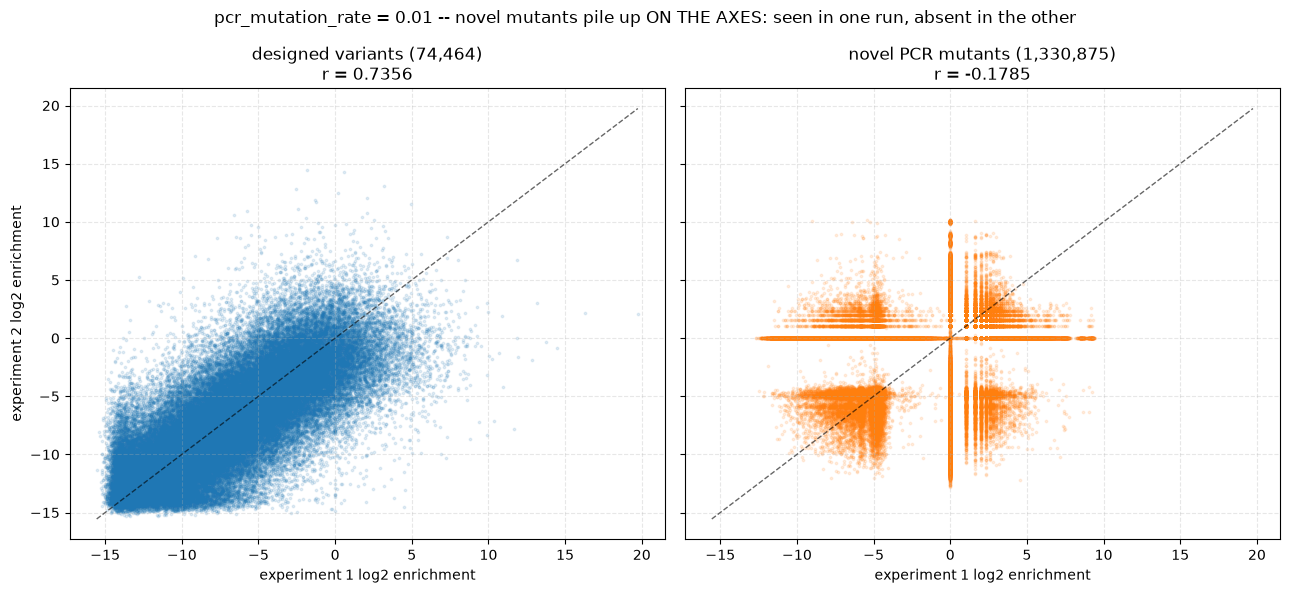

r over the observed union (both panels together) = 0.1032
r over the designed block only                   = 0.7356


In [28]:
# --- experiment 1 vs experiment 2 on the OBSERVED sequences, at DETAIL_RATE ---------------
t2  = detail_p4["t2"]
obs = detail_p4["obs"]
is_novel = np.zeros(d0_ext, bool); is_novel[d0:] = True
m_des, m_nov = obs & ~is_novel, obs & is_novel
lim = [min(t2[0][obs].min(), t2[1][obs].min()), max(t2[0][obs].max(), t2[1][obs].max())]

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, mask, name, col in [(axes[0], m_des, f"designed variants ({int(m_des.sum()):,})", "tab:blue"),
                            (axes[1], m_nov, f"novel PCR mutants ({int(m_nov.sum()):,})", "tab:orange")]:
    ax.scatter(t2[0][mask], t2[1][mask], s=3, alpha=0.12, color=col)
    ax.plot(lim, lim, "k--", lw=1, alpha=0.6)
    ax.set_xlabel("experiment 1 log2 enrichment")
    ax.set_title(f"{name}\nr = {pearson(t2[0][mask], t2[1][mask]):.4f}")
    ax.grid(True, linestyle="--", alpha=0.3)
axes[0].set_ylabel("experiment 2 log2 enrichment")
fig.suptitle(f"pcr_mutation_rate = {DETAIL_RATE:g} -- novel mutants pile up ON THE AXES: "
             f"seen in one run, absent in the other")
fig.tight_layout()
plt.show()

print(f"r over the observed union (both panels together) = {pearson(t2[0][obs], t2[1][obs]):.4f}")
print(f"r over the designed block only                   = {pearson(t2[0][:d0], t2[1][:d0]):.4f}")

In [29]:
# --- the biggest novel clones: born early in PCR, huge in one run, absent in the other -----
l0_1, l2_1 = detail_p4["runs"][0]
l2_2       = detail_p4["runs"][1][1]
t2         = detail_p4["t2"]
top        = d0 + np.argsort(-l2_1[d0:])[:15]

AA = np.array(list(AA_LABELS))
print(f"pcr_mutation_rate = {DETAIL_RATE:g}   (eps = {eps}, so a 7-mer absent at lambda0p "
      f"scores exactly log2(reads))\n")
print(f"  {'7-mer':8s} {'exp1 log2':>10} {'exp1 reads':>12} {'exp2 log2':>10} {'exp2 reads':>12}")
for s in top:
    print(f"  {''.join(AA[proto_p4.ext_sequences[s]]):8s} {t2[0][s]:10.2f} {l2_1[s]:12,.0f} "
          f"{t2[1][s]:10.2f} {l2_2[s]:12,.0f}")

det   = [set(np.flatnonzero(r[1][d0:] > 0)) for r in detail_p4["runs"]]
inter = set.intersection(*det)
union = set.union(*det)
print(f"\nnovel 7-mers detected per experiment: {[len(d) for d in det]}")
print(f"shared by all {N_EXP_P4}: {len(inter):,}   union: {len(union):,}   "
      f"Jaccard = {len(inter) / max(len(union), 1):.4f}")
print("\n-> a clone founded in an early PCR cycle reaches thousands of reads; WHICH 7-mer that")
print("   happens to be is random, so it is absent from the other experiment -- the maximal")
print("   possible disagreement, and what drags the observed-union correlation down.")

pcr_mutation_rate = 0.01   (eps = 1, so a 7-mer absent at lambda0p scores exactly log2(reads))

  7-mer     exp1 log2   exp1 reads  exp2 log2   exp2 reads
  THNHGYE        9.43          687       0.00            0
  THEHGKE        4.76          675       0.00            0
  TWNHGKE        9.38          664       0.00            0
  THNHGVE        9.37          661       0.00            0
  PHNHGKE        9.36          655       0.00            0
  THNHGGE        9.36          655       0.00            0
  TDNHGKE        9.36          655       0.00            0
  THNHGKI        9.35          651       0.00            0
  THNHHKE        9.34          648       0.00            0
  TKNHGKE        9.33          643       1.58            2
  THNHGKM        9.33          642       0.00            0
  THNHGDE        9.33          641       0.00            0
  DHNHGKE        9.32          640       0.00            0
  THNPGKE        9.32          638       0.00            0
  TLNHGKE        9.